## Exploaration de données 

## Dictionnaire des Données - Qualité de l'Air Périphérique

Ce dataset contient les mesures horaires des concentrations de polluants atmosphériques sur différents segments du Boulevard Périphérique de Paris.

### Référence Temporelle
* **`time`** : Horodatage de la mesure (Format: AAAA-MM-JJ HH:MM:SS). 

### Segments du Périphérique (Localisation Spatiale)
Chaque colonne représente la concentration moyenne de polluants (en **µg/m³**) sur un tronçon spécifique :

| Colonne | Segment (De $\rightarrow$ Vers) | Zone Géographique |
| :--- | :--- | :--- |
| **Chap-Bagn** | Porte de la Chapelle $\rightarrow$ Porte de Bagnolet | Nord-Est |
| **Bagn-Berc** | Porte de Bagnolet $\rightarrow$ Porte de Bercy | Est |
| **Berc-Ital** | Porte de Bercy $\rightarrow$ Porte d'Italie | Sud-Est |
| **Ital-A6a** | Porte d'Italie $\rightarrow$ Jonction A6a | Sud |
| **A6a-Sevr** | Jonction A6a $\rightarrow$ Porte de Sèvres | Sud-Ouest |
| **Sevr-Aute** | Porte de Sèvres $\rightarrow$ Porte d'Auteuil | Ouest |
| **Aute-Mail** | Porte d'Auteuil $\rightarrow$ Porte de Maillot | Nord-Ouest (16e) |
| **Mail-Chap** | Porte de Maillot $\rightarrow$ Porte de la Chapelle | Nord-Ouest (17e) |

### Polluants Étudiés (Selon le fichier chargé)
* **NO2** : Dioxyde d'azote (lié principalement au trafic routier).
* **PM10** : Particules fines de diamètre inférieur à 10 micromètres.
* **PM2.5** : Particules fines de diamètre inférieur à 2.5 micromètres.

📂 Recherche des fichiers dans : c:\Users\louni\projetEtudeM2\smart-mobility-paris-m2-project\data

EXPLORATION - NO2

📊 Dimensions: 1944 lignes × 9 colonnes

📅 Période: 2026-01-01 00:00:00 à 2026-03-22 23:00:00

💾 Empreinte mémoire (en octets) :
Index          132
time         15552
Chap-Bagn    15552
Bagn-Berc    15552
Berc-Ital    15552
Ital-A6a     15552
A6a-Sevr     15552
Sevr-Aute    15552
Aute-Mail    15552
Mail-Chap    15552
dtype: int64

💾 Total mémoire : 0.13 MB

🔍 Valeurs manquantes:
time          0
Chap-Bagn    15
Bagn-Berc    15
Berc-Ital    15
Ital-A6a     15
A6a-Sevr     15
Sevr-Aute    15
Aute-Mail    15
Mail-Chap    15
dtype: int64


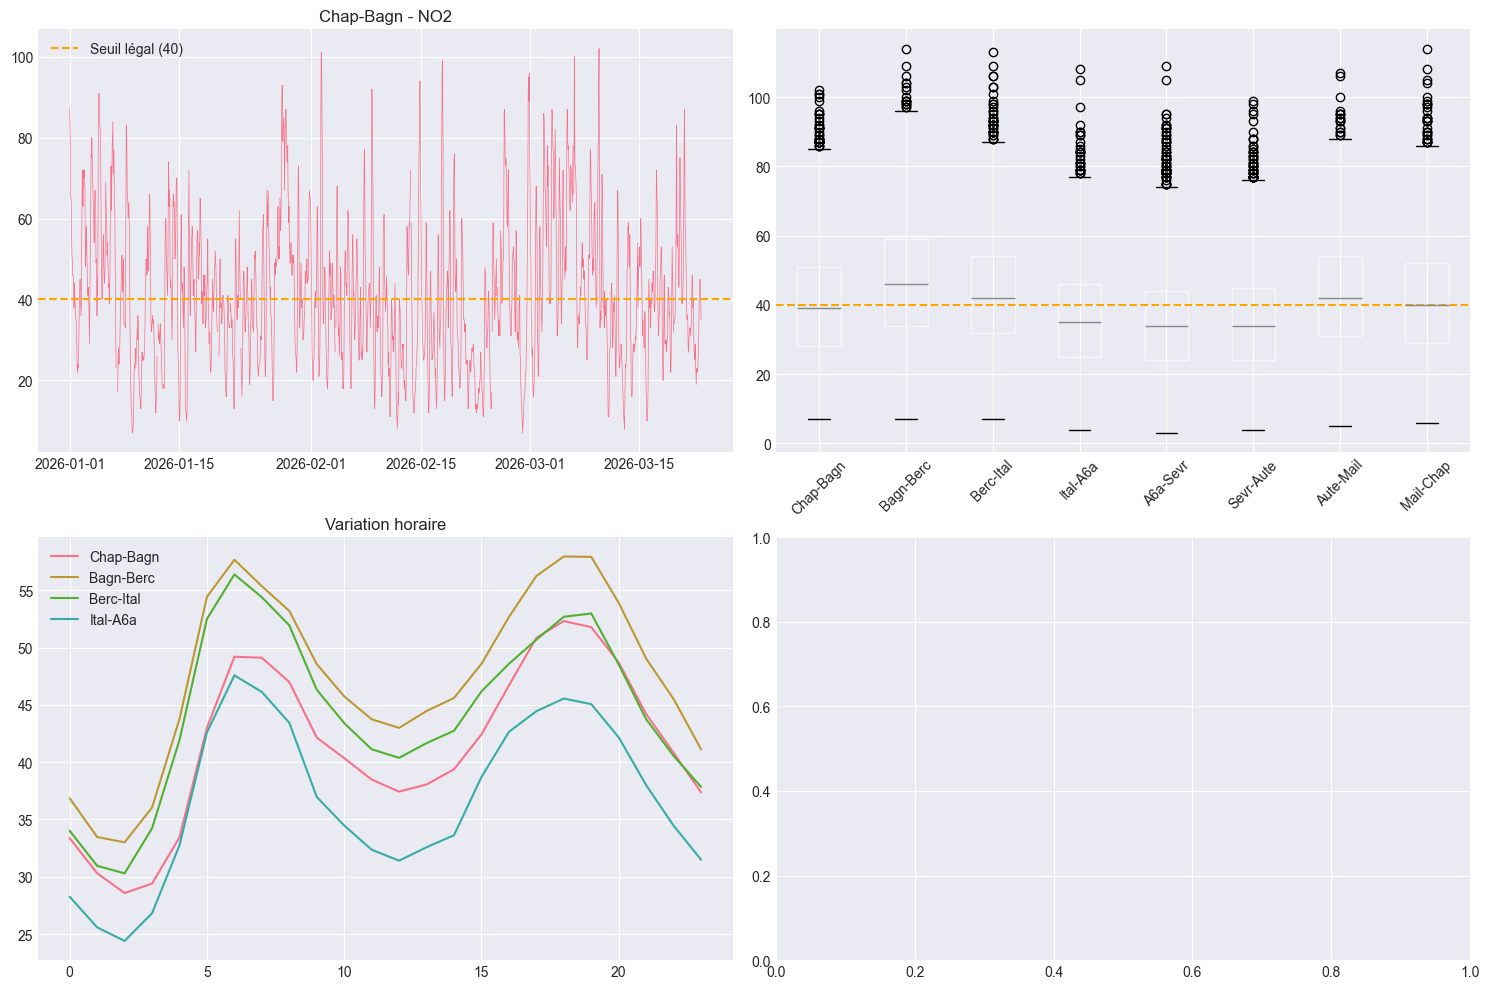

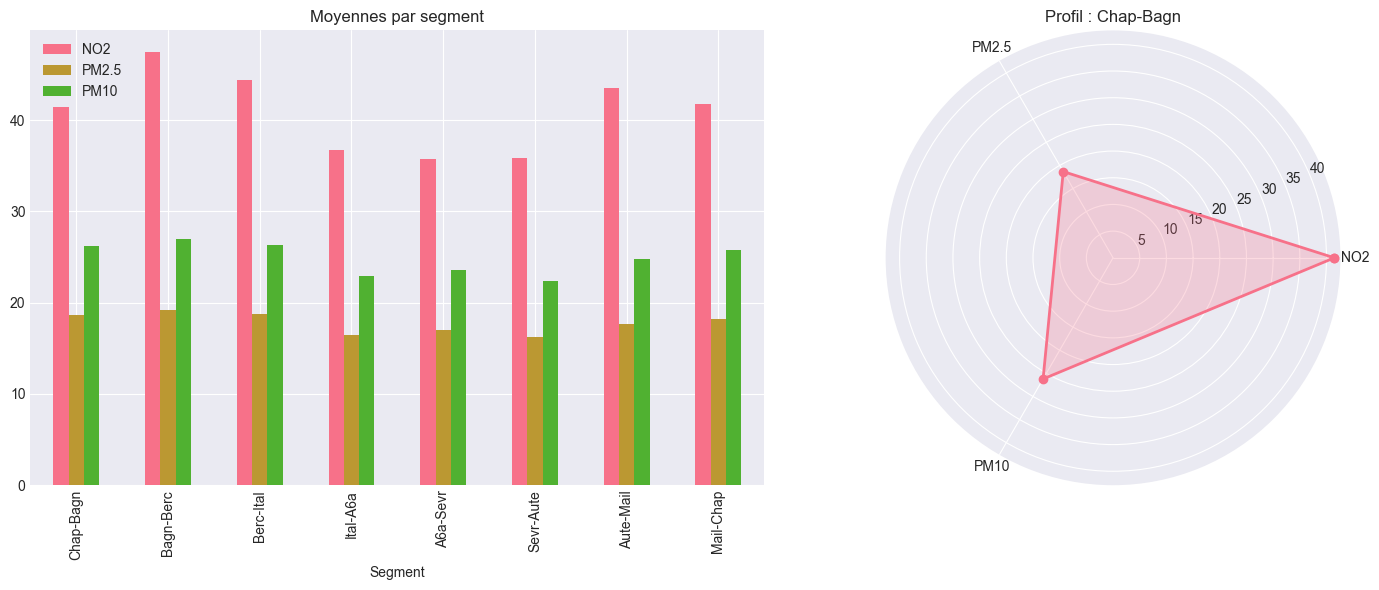

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
from pathlib import Path
from math import pi

warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# =============================================================================
# 1. CHARGEMENT DES DONNÉES (CORRIGÉ POUR LES CHEMINS)
# =============================================================================

def charger_donnees():
    """Charge les trois fichiers de données avec gestion du chemin relatif"""
    # Gestion dynamique du chemin (remonte d'un cran si on est dans /notebooks)
    current_dir = Path(os.getcwd())
    base_path = current_dir.parent if current_dir.name == 'notebooks' else current_dir
    data_dir = base_path / 'data'

    print(f"📂 Recherche des fichiers dans : {data_dir.absolute()}")

    # Noms exacts des fichiers (attention aux accents)
    files = {
        'NO2':  data_dir / '2026_NO2_boulevard_périphérique.csv',
        'PM25': data_dir / '2026_PM25_boulevard_périphérique.csv',
        'PM10': data_dir / '2026_PM10_boulevard_périphérique.csv'
    }

    try:
        df_no2 = pd.read_csv(files['NO2'], parse_dates=['time'])
        df_pm25 = pd.read_csv(files['PM25'], parse_dates=['time'])
        df_pm10 = pd.read_csv(files['PM10'], parse_dates=['time'])
        return df_no2, df_pm25, df_pm10
    except FileNotFoundError as e:
        print(f"❌ Erreur : {e}")
        print(f"Contenu du dossier data : {[f.name for f in data_dir.glob('*.csv')]}")
        return None, None, None

# =============================================================================
# 2. EXPLORATION GÉNÉRALE (CORRIGÉ AVEC MÉMOIRE)
# =============================================================================

def exploration_generale(df, nom_polluant):
    if df is None: return
    print(f"\n{'='*60}")
    print(f"EXPLORATION - {nom_polluant}")
    print(f"{'='*60}")
    
    print(f"\n📊 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"\n📅 Période: {df['time'].min()} à {df['time'].max()}")
    
    print(f"\n💾 Empreinte mémoire (en octets) :\n{df.memory_usage(deep=True)}")
    print(f"\n💾 Total mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print(f"\n🔍 Valeurs manquantes:\n{df.isnull().sum()}")

# =============================================================================
# 3. VISUALISATION TEMPORELLE (CORRIGÉ AVEC SEUILS)
# =============================================================================

def visualisation_temporelle(df, nom_polluant):
    if df is None: return
    segments = [col for col in df.columns if col not in ['time', 'heure', 'jour_semaine', 'jour']]
    
    # --- PLOTLY (Interactif) ---
    fig = make_subplots(rows=2, cols=1, vertical_spacing=0.12)
    for segment in segments:
        fig.add_trace(go.Scatter(x=df['time'], y=df[segment], name=segment), row=1, col=1)
    
    # Ajout ligne de seuil sur Plotly
    seuil = 40 if nom_polluant == 'NO2' else (50 if nom_polluant == 'PM10' else 20)
    fig.add_hline(y=seuil, line_dash="dash", line_color="orange", annotation_text="Seuil légal")
    
    fig.show()
    
    # --- MATPLOTLIB (Statique avec Seuils) ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Série temporelle + Seuil
    axes[0, 0].plot(df['time'], df[segments[0]], linewidth=0.5)
    axes[0, 0].axhline(y=seuil, color='orange', linestyle='--', label=f'Seuil légal ({seuil})')
    axes[0, 0].set_title(f'{segments[0]} - {nom_polluant}')
    axes[0, 0].legend()

    # 2. Boxplot
    df[segments].boxplot(ax=axes[0, 1], rot=45)
    axes[0, 1].axhline(y=seuil, color='orange', linestyle='--')
    
    # 3 & 4. Variation Horaire / Hebdomadaire
    df['heure'] = df['time'].dt.hour
    moy_h = df.groupby('heure')[segments].mean()
    for s in segments[:4]: axes[1, 0].plot(moy_h.index, moy_h[s], label=s)
    axes[1, 0].set_title('Variation horaire')
    axes[1, 0].legend()
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# 7. COMPARAISON (CORRIGÉ : RADAR CHART FIX)
# =============================================================================

def comparaison_polluants(df_no2, df_pm25, df_pm10):
    if df_no2 is None: return
    segments = [col for col in df_no2.columns if col not in ['time', 'heure', 'jour_semaine', 'jour']]
    
    moyennes = pd.DataFrame({
        'Segment': segments,
        'NO2': [df_no2[s].mean() for s in segments],
        'PM2.5': [df_pm25[s].mean() for s in segments],
        'PM10': [df_pm10[s].mean() for s in segments]
    })

    # FIX DU RADAR CHART : Création d'une figure spécifique
    fig = plt.figure(figsize=(15, 6))
    
    # Bar plot
    ax1 = fig.add_subplot(121)
    moyennes.plot(kind='bar', x='Segment', ax=ax1)
    ax1.set_title("Moyennes par segment")

    # Radar chart
    ax2 = fig.add_subplot(122, projection='polar')
    categories = ['NO2', 'PM2.5', 'PM10']
    N = len(categories)
    
    # Valeurs pour le premier segment
    values = moyennes.loc[0, categories].values.flatten().tolist()
    values += values[:1] # Fermer le cercle
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax2.plot(angles, values, 'o-', linewidth=2)
    ax2.fill(angles, values, alpha=0.25)
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(categories)
    ax2.set_title(f"Profil : {moyennes.loc[0, 'Segment']}")
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# EXÉCUTION
# =============================================================================

if __name__ == "__main__":
    df_no2, df_pm25, df_pm10 = charger_donnees()
    
    if df_no2 is not None:
        exploration_generale(df_no2, "NO2")
        visualisation_temporelle(df_no2, "NO2")
        comparaison_polluants(df_no2, df_pm25, df_pm10)
        # Note : tu peux appeler les autres fonctions (analyse_spatiale, etc.) de la même manière

Analyse et Interprétation des Résultats
1. Analyse Temporelle (Séries Temporelles)
Les graphiques des séries temporelles (première et deuxième image) révèlent des tendances saisonnières et journalières marquées :
Cycles journaliers : On observe une alternance claire entre des pics de pollution en journée et des creux la nuit.
Dépassements fréquents : La ligne pointillée orange (Seuil légal de 40 µg/m³) est fréquemment franchie, particulièrement sur les segments comme Chap-Bagn et Bagn-Berc.
Événements extrêmes : Des pics soudains (ex: fin janvier, mi-février) montrent des épisodes de pollution intense où les valeurs dépassent les 100 µg/m³, nécessitant une attention particulière pour la modélisation (gestion des outliers).
2. Analyse Statistique (Boxplots)
Le boxplot de droite permet de comparer la distribution des données par segment :
Médianes variables : Certains segments (Bagn-Berc, Berc-Ital) présentent des médianes plus élevées et un plus grand nombre d'outliers (points au-dessus de la moustache supérieure), indiquant une variabilité plus forte.
Segments "calmes" : Les segments centraux et sud (A6a-Sevr, Sevr-Aute) semblent avoir des distributions légèrement plus resserrées, bien que le seuil de 40 soit souvent dépassé.
3. Variation Horaire Moyenne
Le graphique de "Variation horaire" met en évidence les heures critiques :
Heures de pointe : On distingue deux pics principaux vers 06h-08h (matin) et 18h-20h (soir), corrélant directement avec les embouteillages et l'intensité du trafic.
Heures creuses : La pollution atteint ses niveaux les plus bas aux alentours de 04h-05h du matin et vers 12h (pause déjeuner/trafic réduit).
Segment le plus pollué : La courbe Bagn-Berc (en jaune/orange) se situe généralement au-dessus des autres, suggérant que ce tronçon est le plus exposé aux émissions.
4. Comparaison des Polluants (Barres & Radar)
Le graphique à barres et le diagramme radar comparent les trois polluants (NO2, PM2.5, PM10) :
Dominance du NO2 : Le NO2 (en rose) est systématiquement le polluant le plus élevé, souvent plus du double des concentrations de particules fines (PM2.5 et PM10). Cela confirme l'origine majoritairement automobile du trafic.
Profil homogène : Le diagramme radar pour "Chap-Bagn" montre que le NO2 domine largement le profil de pollution, suivi par le PM10, tandis que le PM2.5 reste en retrait.

## Interprétation des Résultats d'Exploration (Données 2026)

D'après les visualisations générées, plusieurs phénomènes clés de la pollution sur le périphérique parisien peuvent être observés :

### 1. Dépassement des Seuils Légaux (NO2)
* **Observations :** Sur le graphique temporel et les boxplots, on remarque que la ligne pointillée orange ($40\ \mu g/m^3$) est fréquemment franchie sur presque tous les segments.
* **Zones critiques :** Les segments **Bagn-Berc** et **Berc-Ital** présentent les médianes les plus élevées, dépassant souvent le seuil réglementaire annuel.

### 2. Profil Horaire : L'empreinte du Trafic
* **Double Bosse :** Le graphique de variation horaire montre clairement deux pics de pollution correspondant aux heures de pointe :
    * **Matin (6h - 9h) :** Montée rapide des concentrations lors des flux entrants.
    * **Soir (17h - 20h) :** Pic plus étalé lors des flux sortants.
* **Bagn-Berc** semble être systématiquement le segment le plus exposé durant ces périodes.

### 3. Analyse Spatiale et Typologie des Polluants
* **Dominance du NO2 :** Le diagramme à barres comparatif montre que le $NO_2$ est le polluant majeur en termes de concentration brute, ce qui confirme l'origine principalement automobile de la pollution.
* **Profil Radar :** Le profil radar du segment **Chap-Bagn** montre une forte signature en $NO_2$, tandis que les particules fines ($PM_{10}$ et $PM_{2.5}$) restent plus stables d'un segment à l'autre, suggérant une pollution de fond plus homogène pour ces dernières.

### 4. Valeurs Extrêmes (Outliers)
* Les **boxplots** révèlent de nombreux points isolés au-dessus de $100\ \mu g/m^3$ pour le $NO_2$. Ces "outliers" correspondent probablement à des épisodes de congestion sévère ou à des conditions météorologiques défavorables (inversion thermique) empêchant la dispersion des polluants.